<a href="https://colab.research.google.com/github/Casey-G-da/Airline-tickets-insights/blob/main/lunch_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [2]:
import pandas as pd
import os

# Assuming the dataset file is named 'StudentsPerformance.csv' within the downloaded path
# First, let's list the contents of the 'path' directory to confirm the file name
print(f"Contents of the dataset directory '{path}':\n{os.listdir(path)}")

# If 'StudentsPerformance.csv' is present, load it.
# If not, you might need to adjust the filename based on the above output.
data_file = os.path.join(path, 'StudentsPerformance.csv')
df = pd.read_csv(data_file)

print(f"\nNumber of rows and columns: {df.shape}")

Contents of the dataset directory '/kaggle/input/students-performance-in-exams':
['StudentsPerformance.csv']

Number of rows and columns: (1000, 8)


In [3]:
print('Column Names:')
for col in df.columns:
    print(col)

Column Names:
gender
race/ethnicity
parental level of education
lunch
test preparation course
math score
reading score
writing score


The rows are identified by their integer index, from 0 to 999 in this dataset.

In [4]:
display(df.head(10))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


### Linear Regression: 'lunch' vs 'math score'

To analyze the correlation between 'lunch' type and 'math score', we'll perform a linear regression. First, we need to convert the categorical 'lunch' column into a numerical format that the regression model can understand.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
# We'll use OneHotEncoder to convert 'lunch' into a numerical feature
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
lunch_encoded = encoder.fit_transform(df[['lunch']])

# Create a DataFrame for the encoded lunch feature
lunch_df = pd.DataFrame(lunch_encoded, columns=encoder.get_feature_names_out(['lunch']))

# The target variable is 'math score'
y = df['math score']

# If 'lunch_free/reduced' exists, use it as the feature, otherwise use 'lunch_standard'
# This ensures we pick one of the generated columns.
if 'lunch_free/reduced' in lunch_df.columns:
    X = lunch_df[['lunch_free/reduced']]
    feature_name = 'Free/Reduced Lunch (1=Yes, 0=No)'
elif 'lunch_standard' in lunch_df.columns:
    X = lunch_df[['lunch_standard']]
    feature_name = 'Standard Lunch (1=Yes, 0=No)'
else:
    raise ValueError("Neither 'lunch_free/reduced' nor 'lunch_standard' found after encoding.")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
R2_score = model.score(X_test, y_test)
print(f"R-squared score: {R2_score:.4f}")
print(f"Coefficient for {feature_name}: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


R-squared score: 0.0683
Coefficient for Free/Reduced Lunch (1=Yes, 0=No): -11.55
Intercept: 70.50


The coefficient indicates the change in 'math score' for a one-unit change in the 'lunch' variable (e.g., switching from 'standard' to 'free/reduced' if 'free/reduced' is the feature, or vice versa). A positive coefficient means 'math score' increases with that lunch type, while a negative coefficient means it decreases.

/tmp/ipykernel_652/950142223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['lunch'], y=df['math score'], palette='viridis')


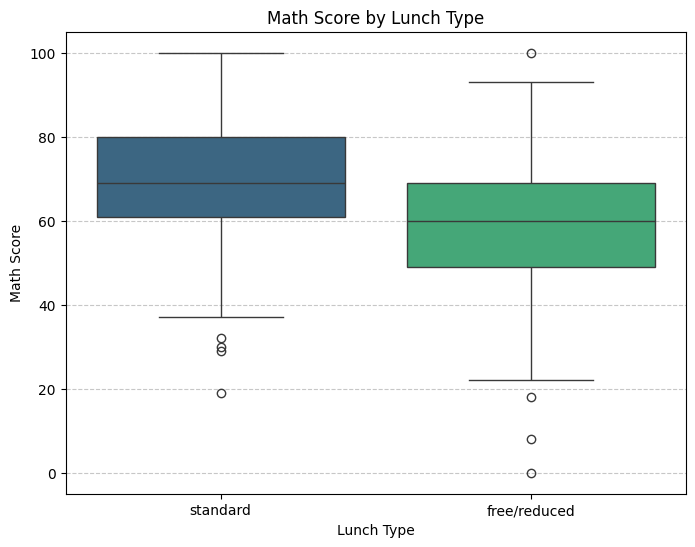

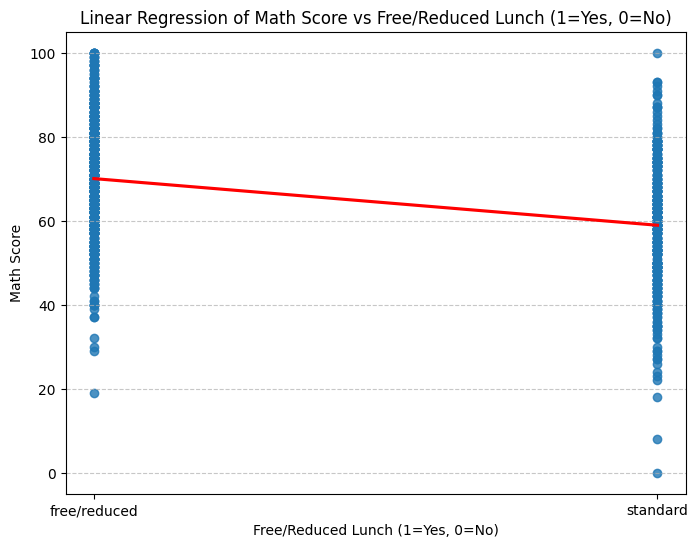

In [6]:
# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['lunch'], y=df['math score'], palette='viridis')
plt.title('Math Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Math Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Another way to visualize, showing the regression line if applicable (for a binary feature, it's essentially connecting two means)
plt.figure(figsize=(8, 6))
sns.regplot(x=X.iloc[:,0], y=y, ci=None, line_kws={'color':'red'})
plt.title(f'Linear Regression of Math Score vs {feature_name}')
plt.xlabel(feature_name)
plt.ylabel('Math Score')
plt.xticks([0, 1], encoder.categories_[0]) # Label x-axis with original categories
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()